# Lista de Exercícios sobre Pandas

## Informações Sobre a Base de Dados que será utilizado para a resolução dos exercícios:

- Esta base de dados contém informações sobre diferentes barras de chocolate avaliadas por especialistas. Cada linha representa uma barra analisada, com dados referentes ao fabricante, origem do grão, porcentagem de cacau, avaliação, entre outros.

    - **Company (Maker-if Known)**: Nome da empresa responsável por fabricar a barra de chocolate.

    - **Specific Bean Origin or Bar Name**: Região geográfica específica de origem do grão de cacau usado ou nome dado à barra.

    - **REF**: Valor numérico associado ao momento em que a avaliação foi registrada na base de dados. Quanto maior o número, mais recente a avaliação.

    - **Review Date**: Ano de publicação da avaliação da barra de chocolate.

    - **Cocoa Percent**: Porcentagem de cacau presente na barra de chocolate, que indica seu nível de pureza ou intensidade.

    - **Company Location**: País onde a empresa fabricante está localizada.

    - **Rating**: Avaliação dada à barra de chocolate por especialistas, geralmente em uma escala numérica.

    - **Bean Type**: Tipo (ou variedade) do grão de cacau utilizado, se informado (ex: Criollo, Forastero, Trinitario).

    - **Broad Bean Origin**: Região geográfica ampla de origem do grão de cacau, como um país ou continente.

## Exercício 1: Abrindo uma Base de Dados

Utilizando a biblioteca Pandas, realize as primeiras etapas para iniciar a análise de uma base de dados:

- Carregue a base de dados `chocolate.csv` que está dentro da pasta `dados`.

- Exiba as 5 primeiras e últimas linhas do DataFrame resultante.

In [100]:
# Resolução do Exercício:

# Importando a biblioteca Pandas
import pandas as pd

# Carregando a base de dados
BASE = 'dados/chocolate.csv'
df = pd.read_csv(BASE)

df.head()

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru


In [101]:
# Ajustes na base
df.columns = df.columns.str.replace('\n', ' ', regex=True).str.strip() # Removendo \n da base de dados
df.columns.values[0] = 'Company' # Alterando o nome para que fique mais fácil a análise

# Imprimindo as 5 primeiras linhas
df.head()

,Company,Specific Bean Origin or Bar Name,REF,Review Date,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru


In [102]:
# Imprimindo as 5 últimas linhas
df.tail()

,Company,Specific Bean Origin or Bar Name,REF,Review Date,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
1790,Zotter,Peru,647,2011,70%,Austria,3.75,,Peru
1791,Zotter,Congo,749,2011,65%,Austria,3.00,Forastero,Congo
1792,Zotter,Kerala State,749,2011,65%,Austria,3.50,Forastero,India
1793,Zotter,Kerala State,781,2011,62%,Austria,3.25,,India
1794,Zotter,"Brazil, Mitzi Blue",486,2010,65%,Austria,3.00,,Brazil


## Exercício 2: Checagem Inicial da Base de Dados

- Usando a biblioteca Pandas, realize uma análise exploratória inicial para conhecer melhor a estrutura da base `chocolate.csv`. Para isso, realize as seguintes tarefas:

    - Verifique o número total de linhas e colunas da base.

    - Liste o nome de todas as colunas.

    - Identifique o tipo de dado de cada coluna.

    - Verifique se existem valores nulos na base.

    - Exiba estatísticas descritivas de todas as colunas numéricas.

    - Exiba estatísticas descritivas de todas as colunas não numéricas.

    - Verifique quantas companhias estão localizadas na França.

    - Verifique quantos valores únicos existem em cada coluna.

    - Verifique quantos tipos de grãos diferentes existem na base.

    - Verifique a quantidade de linhas duplicadas.

    - Conte quantas vezes cada valor da coluna Rating aparece.

In [103]:
# Resolução do Exercício:

# Verificar número total de linhas e colunas
df.shape

(1795, 9)

In [104]:
# Nome de todas as colunas
df.columns

Index(['Company', 'Specific Bean Origin or Bar Name', 'REF', 'Review Date',
       'Cocoa Percent', 'Company Location', 'Rating', 'Bean Type',
       'Broad Bean Origin'],
      dtype='object')

In [105]:
# Tipo de dado de cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Company                           1795 non-null   object 
 1   Specific Bean Origin or Bar Name  1795 non-null   object 
 2   REF                               1795 non-null   int64  
 3   Review Date                       1795 non-null   int64  
 4   Cocoa Percent                     1795 non-null   object 
 5   Company Location                  1795 non-null   object 
 6   Rating                            1795 non-null   float64
 7   Bean Type                         1794 non-null   object 
 8   Broad Bean Origin                 1794 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 126.3+ KB


In [106]:
# Valores nulos
df.isnull().sum()

Company                             0
Specific Bean Origin or Bar Name    0
REF                                 0
Review Date                         0
Cocoa Percent                       0
Company Location                    0
Rating                              0
Bean Type                           1
Broad Bean Origin                   1
dtype: int64

In [107]:
# Estatística descritiva das colunas numéricas
df.describe()

,REF,Review Date,Rating
count,1795.000000,1795.000000,1795.000000
mean,1035.904735,2012.325348,3.185933
std,552.886365,2.927210,0.478062
min,5.000000,2006.000000,1.000000
25%,576.000000,2010.000000,2.875000
50%,1069.000000,2013.000000,3.250000
75%,1502.000000,2015.000000,3.500000
max,1952.000000,2017.000000,5.000000


In [108]:
# Estatística descritiva das colunas não numéricas
df.describe(exclude="number")

,Company,Specific Bean Origin or Bar Name,Cocoa Percent,Company Location,Bean Type,Broad Bean Origin
count,1795,1795,1795,1795,1794,1794
unique,416,1039,45,60,41,100
top,Soma,Madagascar,70%,U.S.A.,,Venezuela
freq,47,57,672,764,887,214


In [109]:
# Quantidade de companhias francesas
(df['Company Location'] == 'France').sum()

np.int64(156)

In [110]:
# Quantidade de valores únicos em cada coluna
df.nunique()

Company                              416
Specific Bean Origin or Bar Name    1039
REF                                  440
Review Date                           12
Cocoa Percent                         45
Company Location                      60
Rating                                13
Bean Type                             41
Broad Bean Origin                    100
dtype: int64

In [111]:
# Quantidade de companhias diferentes
df["Bean Type"].unique()

array(['\xa0', 'Criollo', 'Trinitario', 'Forastero (Arriba)', 'Forastero',
       'Forastero (Nacional)', 'Criollo, Trinitario',
       'Criollo (Porcelana)', 'Blend', 'Trinitario (85% Criollo)',
       'Forastero (Catongo)', 'Forastero (Parazinho)',
       'Trinitario, Criollo', 'CCN51', 'Criollo (Ocumare)', 'Nacional',
       'Criollo (Ocumare 61)', 'Criollo (Ocumare 77)',
       'Criollo (Ocumare 67)', 'Criollo (Wild)', 'Beniano', 'Amazon mix',
       'Trinitario, Forastero', 'Forastero (Arriba) ASS', 'Criollo, +',
       'Amazon', 'Amazon, ICS', 'EET', 'Blend-Forastero,Criollo',
       'Trinitario (Scavina)', 'Criollo, Forastero', 'Matina',
       'Forastero(Arriba, CCN)', 'Nacional (Arriba)',
       'Forastero (Arriba) ASSS', 'Forastero, Trinitario',
       'Forastero (Amelonado)', nan, 'Trinitario, Nacional',
       'Trinitario (Amelonado)', 'Trinitario, TCGA', 'Criollo (Amarru)'],
      dtype=object)

In [112]:
# Quantidade de linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [113]:
# Quantidade de vezes que cada valor da coluna Rating aparece
df['Rating'].value_counts().sort_values()

Rating
5.00      2
1.75      3
1.00      4
1.50     10
2.25     14
2.00     32
4.00     98
2.50    127
3.75    210
2.75    259
3.25    303
3.00    341
3.50    392
Name: count, dtype: int64

## Exercício 3: Análise exploratória inicial

- Com base nos resultados obtidos no Exercício 2, faça uma análise geral sobre a base de dados `chocolate.csv`.

#### Resolução do Exercício:

- Com o uso de `df.shape` e `df.columns`, foi possível verificar que o número de linhas e colunas está de acordo com a base fornecida, e que os nomes das colunas estão corretos e condizentes com o dicionário de dados.

- Através do `df.info()`, observamos que os tipos de dados estão apropriados. No caso da coluna `Cocoa Percent`, os valores aparecem com o símbolo `%`, o que justifica o tipo `object`.

- A função `df.isnull().sum()` revelou a presença de valores nulos nas colunas `BeanType` e `Broad Bean Origin`, o que exigirá uma análise posterior para entender as causas e decidir o tratamento adequado.

- O comando `df.describe()` forneceu estatísticas descritivas das colunas numéricas, enquanto `df.describe(exclude="number")` revelou que a coluna `BeanType` tem como valor mais frequente um dado ausente (possivelmente um valor vazio ou inválido que não foi reconhecido como nulo pelo Pandas), o que também merece atenção futura.

- A verificação com `df.duplicated().sum()` indicou que não existem linhas duplicadas na base, o que é coerente com o tipo de dados apresentados.

- Por fim, `df['Rating'].value_counts()` mostrou que as avaliações estão mais concentradas no intervalo fechado entre **2.75** e **3.75**, o que pode indicar uma tendência de notas médias a levemente positivas na análise das barras de chocolate.

## Exercício 4: Selecionando Dados do DataFrame

- Neste exercício, vamos praticar diferentes formas de selecionar partes do DataFrame, utilizando métodos como loc, iloc e condições lógicas. O exercício está dividido em três partes:

    - **Parte 1:** Maior e menor valor da coluna `Rating`:

        - Identifique o **maior** e o **menor** valor da coluna Rating, junto com seus respectivos **índices** no DataFrame.

    - **Parte 2:** Utilizando os métodos `loc` e `iloc`:

        - Utilize o `loc` para exibir a linha completa correspondente ao **maior** valor de `Rating`.

        - Utilize o `iloc` para mostrar da linha 60 à 70, apenas as colunas `Company`, `Specific Bean Origin or Bar Name` e `Rating`.

    -  **Parte 3:** Seleção por condição:

        - Exiba todas as linhas em que o `Rating` seja **menor** que 2.5 e a origem ampla do grão (`Broad Bean Origin`) seja Venezuela.

    - **Parte 4:** Seleção por condição utilizando `query`

        - Exiba todas as linhas em que o `Rating` seja **menor** que 2.5 e a origem ampla do grão (`Broad Bean Origin`) seja Venezuela.


In [114]:
# Resolução da parte 1:

# Identificando maior e menor valor com seus respectivos indexs
maior_valor = df['Rating'].max() # maior valor
menor_valor = df['Rating'].min() # menor valor
maior_index = df['Rating'].idxmax() # index do maior valor
menor_index = df['Rating'].idxmin() # index do menor valor

# Print no terminal
print(f'Maior valor: {maior_valor}')
print(f'Menor valor: {menor_valor}')
print(f'Maior index: {maior_index}')
print(f'Menor index: {menor_index}')

Maior valor: 5.0
Menor valor: 1.0
Maior index: 78
Menor index: 326


In [115]:
# Resolução da parte 2:

# Utilizando loc
df.loc[df['Rating'].idxmax()]

Company                                 Amedei
Specific Bean Origin or Bar Name         Chuao
REF                                        111
Review Date                               2007
Cocoa Percent                              70%
Company Location                         Italy
Rating                                     5.0
Bean Type                           Trinitario
Broad Bean Origin                    Venezuela
Name: 78, dtype: object

In [116]:
# Resolução da parte 2:

# Utilizando iloc
df.iloc[60:71, [0, 1, -3]]

,Company,Specific Bean Origin or Bar Name,Rating
60,Amano,Madagascar,3.50
61,Amano,Cuyagua,3.00
62,Amano,Ocumare,3.75
63,Amatller (Simon Coll),Ghana,3.00
64,Amatller (Simon Coll),Ecuador,2.75
65,Amatller (Simon Coll),Ecuador,2.75
66,Amatller (Simon Coll),Ghana,3.00
67,Amazona,"LamasdelChanka, San Martin, Oro Verde coop",3.25
68,Amazona,"Bellavista Gran Pajeten, San Martin",3.50
69,Ambrosia,Belize,3.00


In [117]:
# Resolução da parte 3:

# Utilizando condições e and
df[(df['Rating'] < 2.5) & (df['Broad Bean Origin'] == 'Venezuela')]

,Company,Specific Bean Origin or Bar Name,REF,Review Date,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
125,Artisan du Chocolat,Venezuela,486,2010,100%,U.K.,1.75,,Venezuela
283,Cacao Atlanta,Patanemo,600,2010,75%,U.S.A.,2.25,,Venezuela
287,Cacao Barry,Venezuela,141,2007,72%,France,2.00,,Venezuela
1179,Nibble,Patanemo,1526,2015,72%,U.S.A.,2.25,Criollo,Venezuela
1317,Pralus,Cuyagua,451,2009,75%,France,2.00,,Venezuela
1404,Rozsavolgyi,"Rio Caribe Superior, Paria Penninsula",871,2012,76%,Hungary,2.25,Trinitario,Venezuela
1658,Theo,"Venezuela; Barinos, Merida, Tachron",188,2007,91%,U.S.A.,2.00,Blend,Venezuela


In [126]:
# Resolução da parte 4: 
df.query("`Rating` < 2.5 and `Broad Bean Origin` == 'Venezuela'")

,Company,Specific Bean Origin or Bar Name,REF,Review Date,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
125,Artisan du Chocolat,Venezuela,486,2010,100%,U.K.,1.75,Não Identificado,Venezuela
283,Cacao Atlanta,Patanemo,600,2010,75%,U.S.A.,2.25,Não Identificado,Venezuela
287,Cacao Barry,Venezuela,141,2007,72%,France,2.00,Não Identificado,Venezuela
1178,Nibble,Patanemo,1526,2015,72%,U.S.A.,2.25,Criollo,Venezuela
1316,Pralus,Cuyagua,451,2009,75%,France,2.00,Não Identificado,Venezuela
1403,Rozsavolgyi,"Rio Caribe Superior, Paria Penninsula",871,2012,76%,Hungary,2.25,Trinitario,Venezuela
1656,Theo,"Venezuela; Barinos, Merida, Tachron",188,2007,91%,U.S.A.,2.00,Blend,Venezuela


## Exercício 5: Tratamento de valores ausentes

- Neste exercício, o foco será o tratamento de dados ausentes ou inconsistentes na base `chocolate.csv`.

    - **Parte 1:** Remoção de valores nulos reais:

        - Identifique e exiba as duas linhas que possuem valores nulos reais na base.

        - Em seguida, **remova** essas linhas do DataFrame.

    - **Parte 2:** Correção de valores ausentes não reconhecidos:

        - A coluna `Bean Type` possui entradas que, apesar de visualmente vazias, não são reconhecidas como nulas pelo Pandas, então, substitua essas entradas pela string `Não Identificado` para padronizar os dados da coluna.

In [119]:
# Resolução da parte 1:

# Identificando em quais colunas estão os valores nulos
df.isnull().sum()

Company                             0
Specific Bean Origin or Bar Name    0
REF                                 0
Review Date                         0
Cocoa Percent                       0
Company Location                    0
Rating                              0
Bean Type                           1
Broad Bean Origin                   1
dtype: int64

In [120]:
# Printando a fileira onde possui o valor nulo na coluna Bean Type
df[df['Bean Type'].isna()]

,Company,Specific Bean Origin or Bar Name,REF,Review Date,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
1544,Soma,"Three Amigos(Chuao, Wild Bolivia, D.R.)",676,2011,70%,Canada,4.0,NaN,"Ven, Bolivia, D.R."


In [121]:
# Printando a fileira onde possui o valor nulo na coluna Broad Bean Origin
df[df['Broad Bean Origin'].isna()]

,Company,Specific Bean Origin or Bar Name,REF,Review Date,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
1072,Mast Brothers,Madagascar,999,2012,72%,U.S.A.,2.5,Trinitario,NaN


In [122]:
# Mostrando quantidade de linhas antes de apagar as fileiras com valores nulos
df.shape

(1795, 9)

In [123]:
# Apagando os valores nulos das colunas Bean Type e Broad Bean Origin
df = df.dropna()
df = df.reset_index(drop=True) # Resetar o index de todos os dados

# Mostrando que a quantidade de linhas diminuiu em 2
df.shape

(1793, 9)

In [124]:
# Resolução da parte 2:

# Primeiro é necessário saber como esse valor ausenta é chamado
df['Bean Type'].unique() # É possível notar que esses valores constam como '\xa0'

array(['\xa0', 'Criollo', 'Trinitario', 'Forastero (Arriba)', 'Forastero',
       'Forastero (Nacional)', 'Criollo, Trinitario',
       'Criollo (Porcelana)', 'Blend', 'Trinitario (85% Criollo)',
       'Forastero (Catongo)', 'Forastero (Parazinho)',
       'Trinitario, Criollo', 'CCN51', 'Criollo (Ocumare)', 'Nacional',
       'Criollo (Ocumare 61)', 'Criollo (Ocumare 77)',
       'Criollo (Ocumare 67)', 'Criollo (Wild)', 'Beniano', 'Amazon mix',
       'Trinitario, Forastero', 'Forastero (Arriba) ASS', 'Criollo, +',
       'Amazon', 'Amazon, ICS', 'EET', 'Blend-Forastero,Criollo',
       'Trinitario (Scavina)', 'Criollo, Forastero', 'Matina',
       'Forastero(Arriba, CCN)', 'Nacional (Arriba)',
       'Forastero (Arriba) ASSS', 'Forastero, Trinitario',
       'Forastero (Amelonado)', 'Trinitario, Nacional',
       'Trinitario (Amelonado)', 'Trinitario, TCGA', 'Criollo (Amarru)'],
      dtype=object)

In [125]:
# Substituindo os valores ausentes por 'Não Identificado'
df['Bean Type'] = df['Bean Type'].replace('\xa0', 'Não Identificado')
df['Bean Type'].unique()

array(['Não Identificado', 'Criollo', 'Trinitario', 'Forastero (Arriba)',
       'Forastero', 'Forastero (Nacional)', 'Criollo, Trinitario',
       'Criollo (Porcelana)', 'Blend', 'Trinitario (85% Criollo)',
       'Forastero (Catongo)', 'Forastero (Parazinho)',
       'Trinitario, Criollo', 'CCN51', 'Criollo (Ocumare)', 'Nacional',
       'Criollo (Ocumare 61)', 'Criollo (Ocumare 77)',
       'Criollo (Ocumare 67)', 'Criollo (Wild)', 'Beniano', 'Amazon mix',
       'Trinitario, Forastero', 'Forastero (Arriba) ASS', 'Criollo, +',
       'Amazon', 'Amazon, ICS', 'EET', 'Blend-Forastero,Criollo',
       'Trinitario (Scavina)', 'Criollo, Forastero', 'Matina',
       'Forastero(Arriba, CCN)', 'Nacional (Arriba)',
       'Forastero (Arriba) ASSS', 'Forastero, Trinitario',
       'Forastero (Amelonado)', 'Trinitario, Nacional',
       'Trinitario (Amelonado)', 'Trinitario, TCGA', 'Criollo (Amarru)'],
      dtype=object)

## Exercício 6: Agrupamentos e visualização de dados

- Neste exercício, vamos praticar diferentes formas de agrupar e visualizar os dados com base no ano de avaliação (`Review Date`) e nas notas (`Rating`).

    - **Parte 1:** Agrupamento com `groupby`

        - Agrupe os dados por `Review Date` (como index) e calcule:

            - A média da coluna `REF`;

            - A média da coluna `Rating`;

            - A quantidade de avaliações (você pode contar usando a coluna `Company`, basta renomeá-la depois).

        - Em seguida, ainda utilizando `groupby`, crie um gráfico de barras que mostre, para cada ano, quantas vezes cada nota (`Rating`) apareceu.

    - **Parte 2:** Agrupamento com `pivot_table`

        - Refaça o agrupamento da parte anterior utilizando a função `pivot_table` para calcular:

            - A média da coluna `REF`;

            - A média da coluna `Rating`;

            - A quantidade de avaliações (você pode contar usando a coluna `Company`, basta renomeá-la depois).
        
        - Em seguida, gere um gráfico de barras com `pivot_table` que mostre, para cada ano (`Review Date`), a distribuição de notas (`Rating`), com cada nota representada por uma cor diferente.

- O resultado do gráfico tem que ser este:

![Reshape-Axis](imagens/ex6_grafico.png)


In [ ]:
# Resolução da parte 1:

# Criando o agrupamento com groupby
df.groupby("Review Date").agg({
    "REF": "mean",
    "Rating": "mean",
    "Company": "count"  # ou qualquer outra coluna que não tenha valores nulos
}).rename(columns={"Company": "Total de Avaliações"})


,REF,Rating,Total de Avaliações
Review Date,,,
2006,54.375000,3.125000,72
2007,151.155844,3.162338,77
2008,256.086022,2.994624,93
2009,389.585366,3.073171,123
2010,540.306306,3.148649,111
2011,703.957317,3.251524,164
2012,900.185567,3.181701,194
2013,1101.152174,3.197011,184
2014,1319.165992,3.189271,247


<Axes: xlabel='Review Date'>

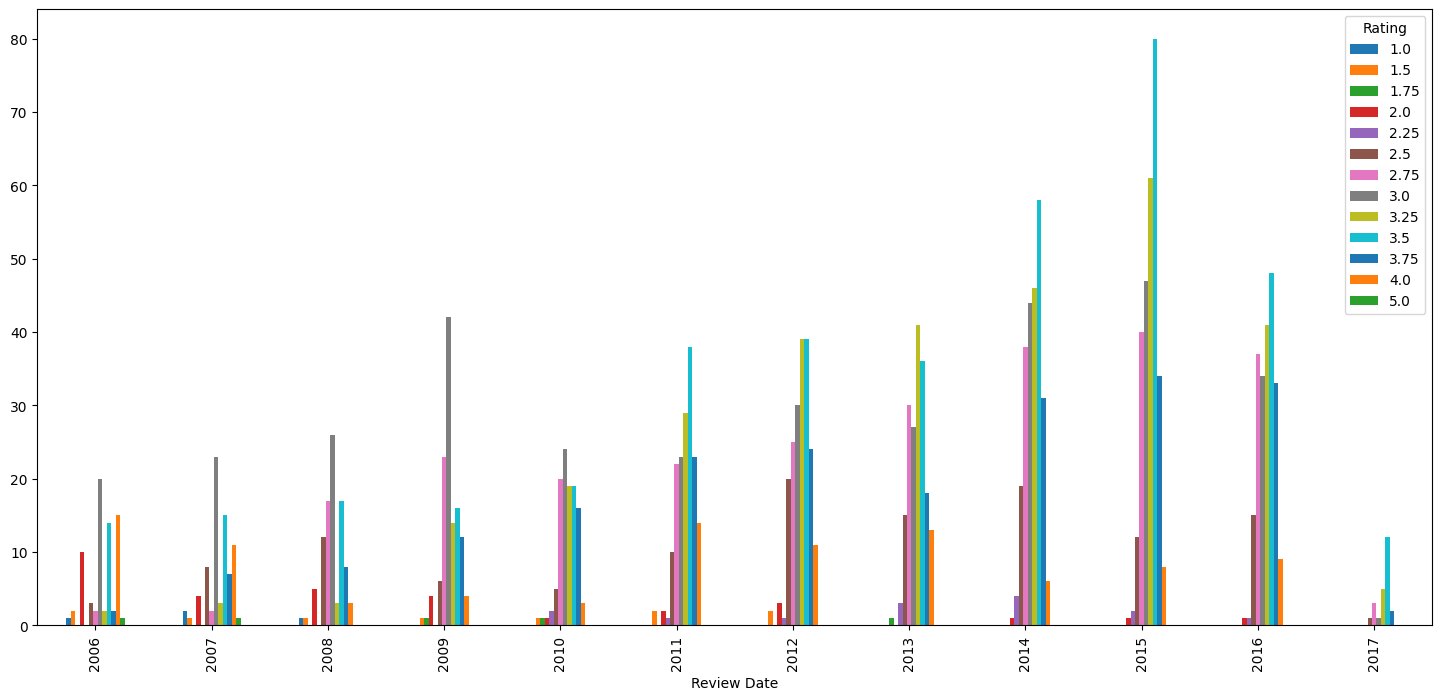

In [ ]:
# Plotando o gráfico com groupby
df.groupby(
    ["Review Date", "Rating"]
).size().unstack().plot(kind="bar", figsize=(18, 8))

# groupby(["Review Date", "Rating"]): agrupa por ano e nota;
# .size(): conta o número de ocorrências para cada par (ano, nota);
# .unstack(): transforma os valores de Rating em colunas (como no pivot_table);

In [ ]:
# Resolução da parte 2:

# Criando o agrupamento com pivot_table
df.pivot_table(
    index="Review Date",
    values=["REF", "Rating", "Company"],
    aggfunc={
        "REF": "mean",
        "Rating": "mean",
        "Company": "count"
    }
).rename(columns={"Company": "Total de Avaliações"})

,Total de Avaliações,REF,Rating
Review Date,,,
2006,72,54.375000,3.125000
2007,77,151.155844,3.162338
2008,93,256.086022,2.994624
2009,123,389.585366,3.073171
2010,111,540.306306,3.148649
2011,164,703.957317,3.251524
2012,194,900.185567,3.181701
2013,184,1101.152174,3.197011
2014,247,1319.165992,3.189271


<Axes: xlabel='Review Date'>

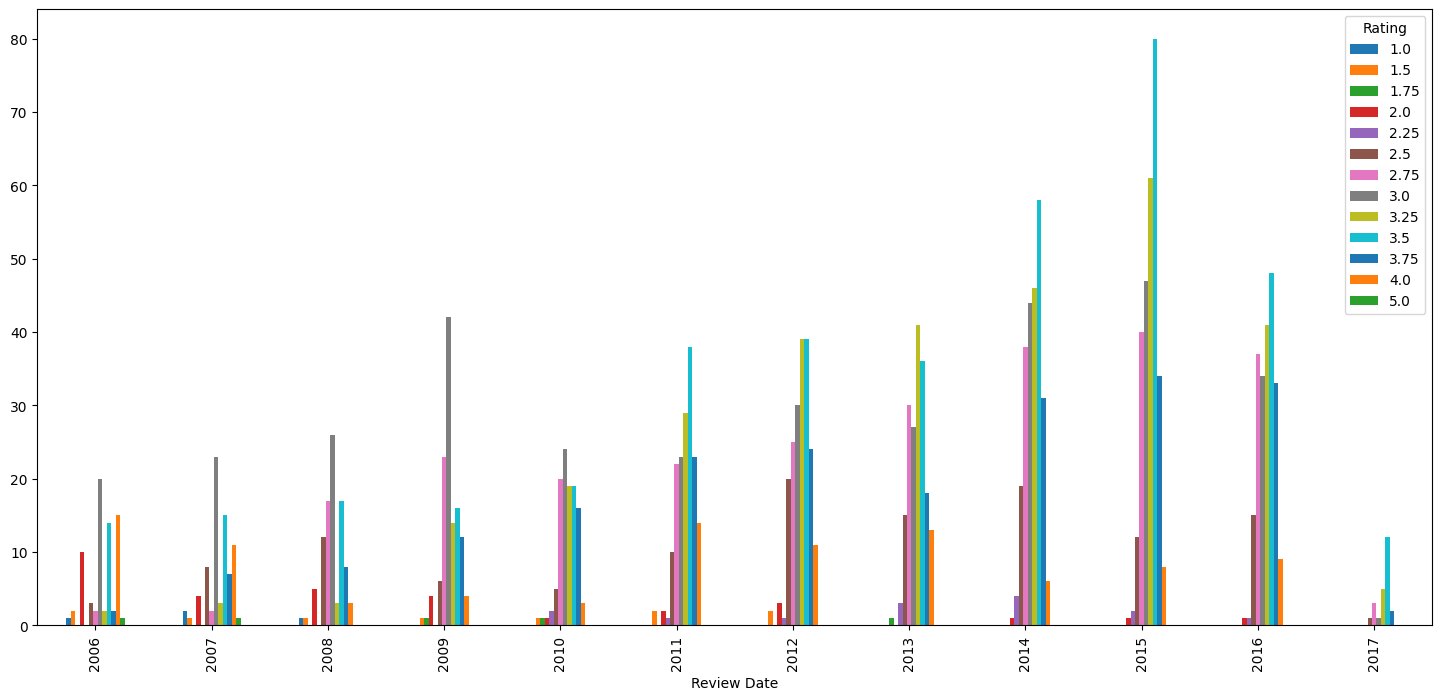

In [ ]:
# Plotando o gráfico com pivot_table
df.pivot_table(
    index="Review Date",
    columns="Rating", 
    values="Company", 
    aggfunc="count"
).plot(kind="bar", figsize=(18, 8))